## Tensorflow

In [14]:
# import libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

In [3]:
dataset=pd.read_csv('./Datasets/diabetes.csv', delimiter=',')

x = dataset.iloc[:, 0:8]  
y = dataset.iloc[:, 8] 

In [4]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
print(f"shape of x : {x.shape}")
x.head(3)

shape of x : (768, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32


In [6]:
print(f"shape of y : {y.shape}")
y.head(3)

shape of y : (768,)


0    1
1    0
2    1
Name: Outcome, dtype: int64

In [ ]:
print(type(x))
print(type(x))

In [8]:
model = Sequential()
model.add(Dense(12, input_shape=(8,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x, y, epochs=150, batch_size=10)

Epoch 1/150


C:\Users\Aman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5984 - loss: 14.2156
Epoch 2/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5291 - loss: 3.5149
Epoch 3/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5802 - loss: 2.0532
Epoch 4/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5755 - loss: 1.7795
Epoch 5/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5756 - loss: 1.5222
Epoch 6/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6096 - loss: 1.3206
Epoch 7/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6138 - loss: 1.1160
Epoch 8/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6770 - loss: 0.8491
Epoch 9/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6016 - loss: 0.9803
Epoch 10/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6685 - loss: 0.7476
Epoch 11/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6631 - loss: 0.7204
Epoch 12/150
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6840 - l

In [64]:
loss, accuracy = model.evaluate(x, y) 
print(f"Model accuracy: {accuracy * 100:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7474 - loss: 0.5189  
Model accuracy: 75.65%


In [65]:
predicted_probabilities = model.predict(x)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [66]:
predicted_classes = (predicted_probabilities > 0.5).astype(int)

In [67]:
# Print the first 10 actual and predicted values 
print("Actual values:\n", y[:10])
print("Predicted probabilities:", predicted_probabilities[:10]) 
print("Predicted classes:", predicted_classes[:10])

Actual values:
 0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: Outcome, dtype: int64
Predicted probabilities: [[0.5889128 ]
 [0.1257297 ]
 [0.68658715]
 [0.11894045]
 [0.80815315]
 [0.35681838]
 [0.374815  ]
 [0.48636281]
 [0.96921223]
 [0.01954579]]
Predicted classes: [[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]]


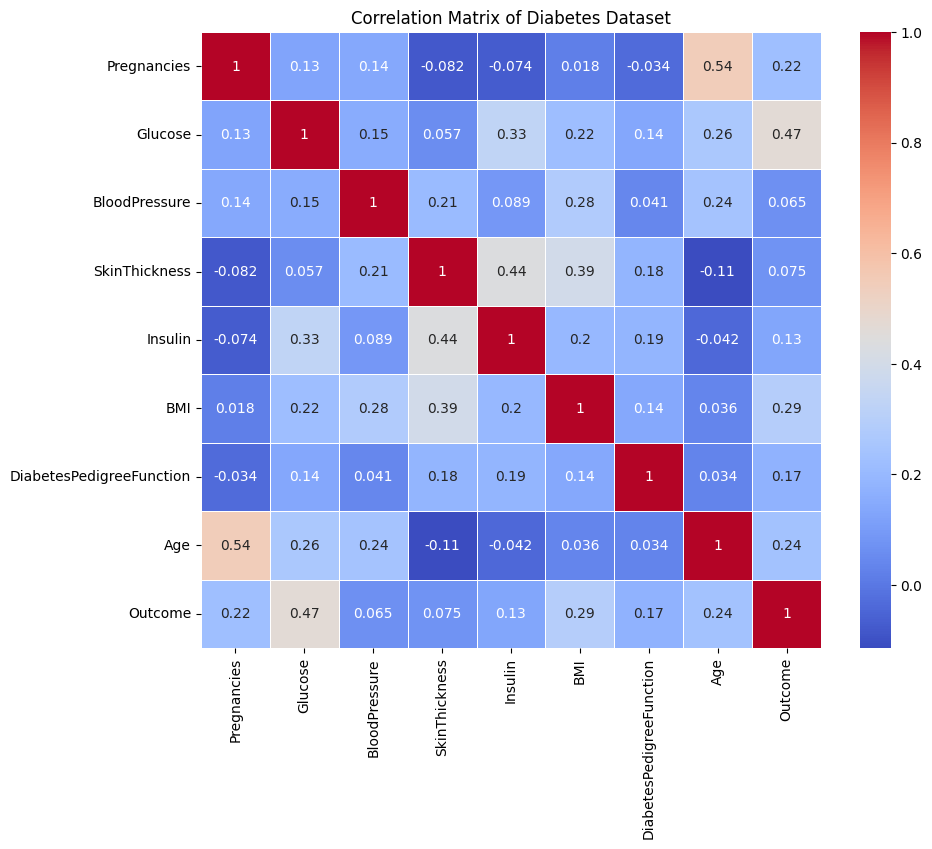

In [20]:
# Assuming df is your DataFrame containing the dataset
plt.figure(figsize=(10, 8))
correlation_matrix = dataset.corr()  # Compute the correlation matrix of the dataset
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

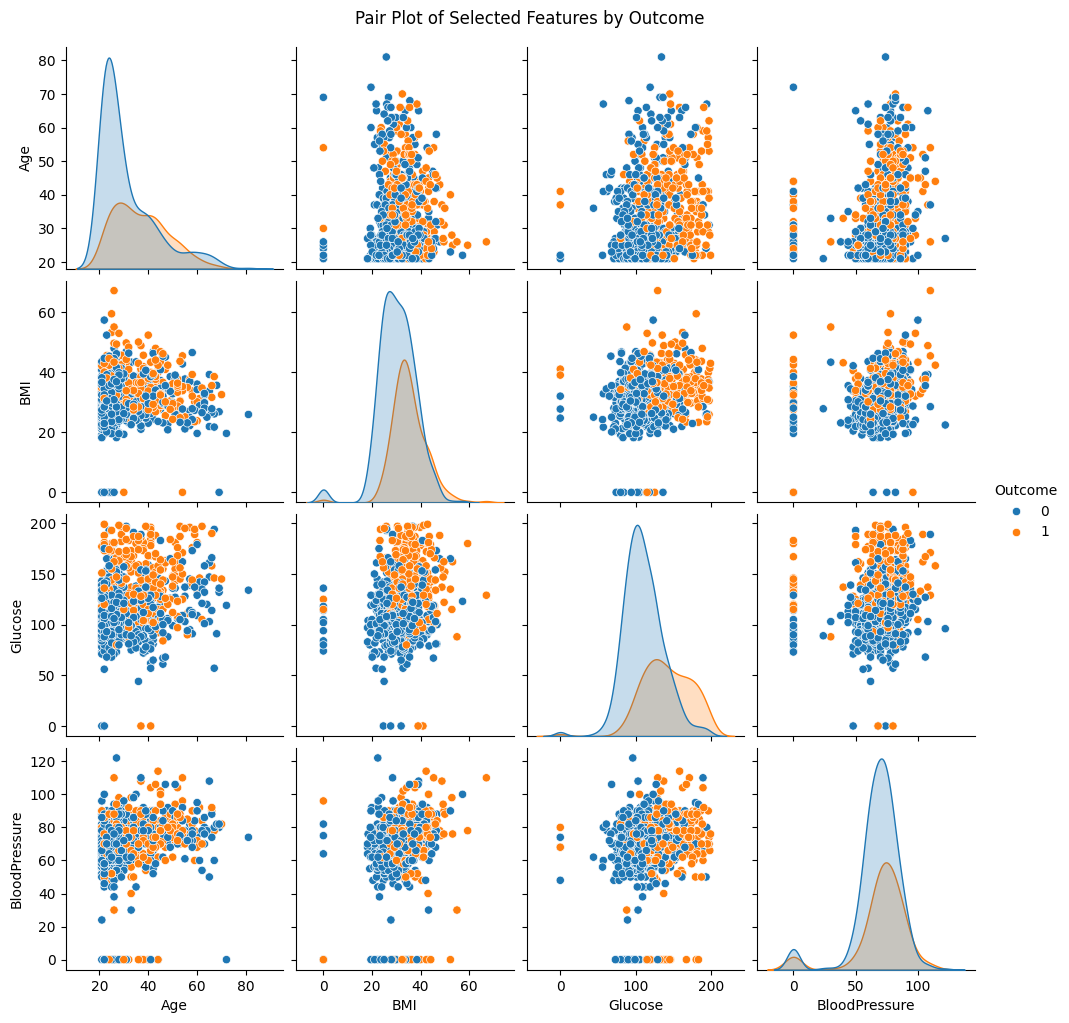

In [22]:
# Pair plot of selected features
sns.pairplot(dataset[['Age', 'BMI', 'Glucose', 'BloodPressure', 'Outcome']], hue='Outcome', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features by Outcome', y=1.02)
plt.show()

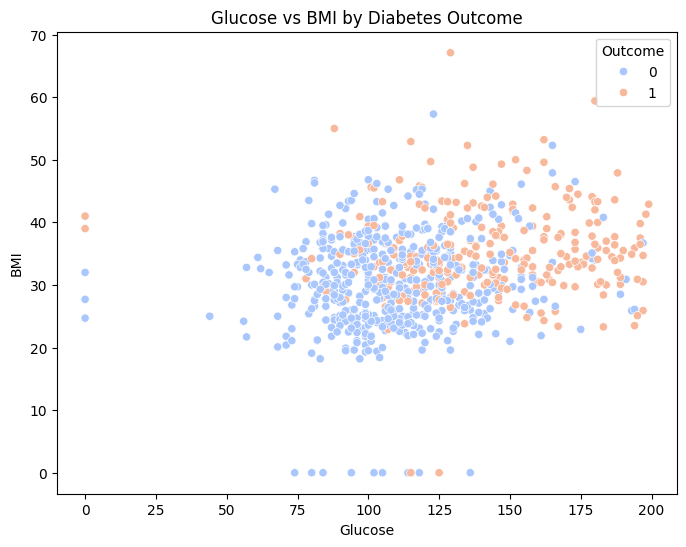

In [23]:
# Scatter plot of Glucose vs BMI with Outcome color-coded
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=dataset, palette='coolwarm')
plt.title('Glucose vs BMI by Diabetes Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.show()

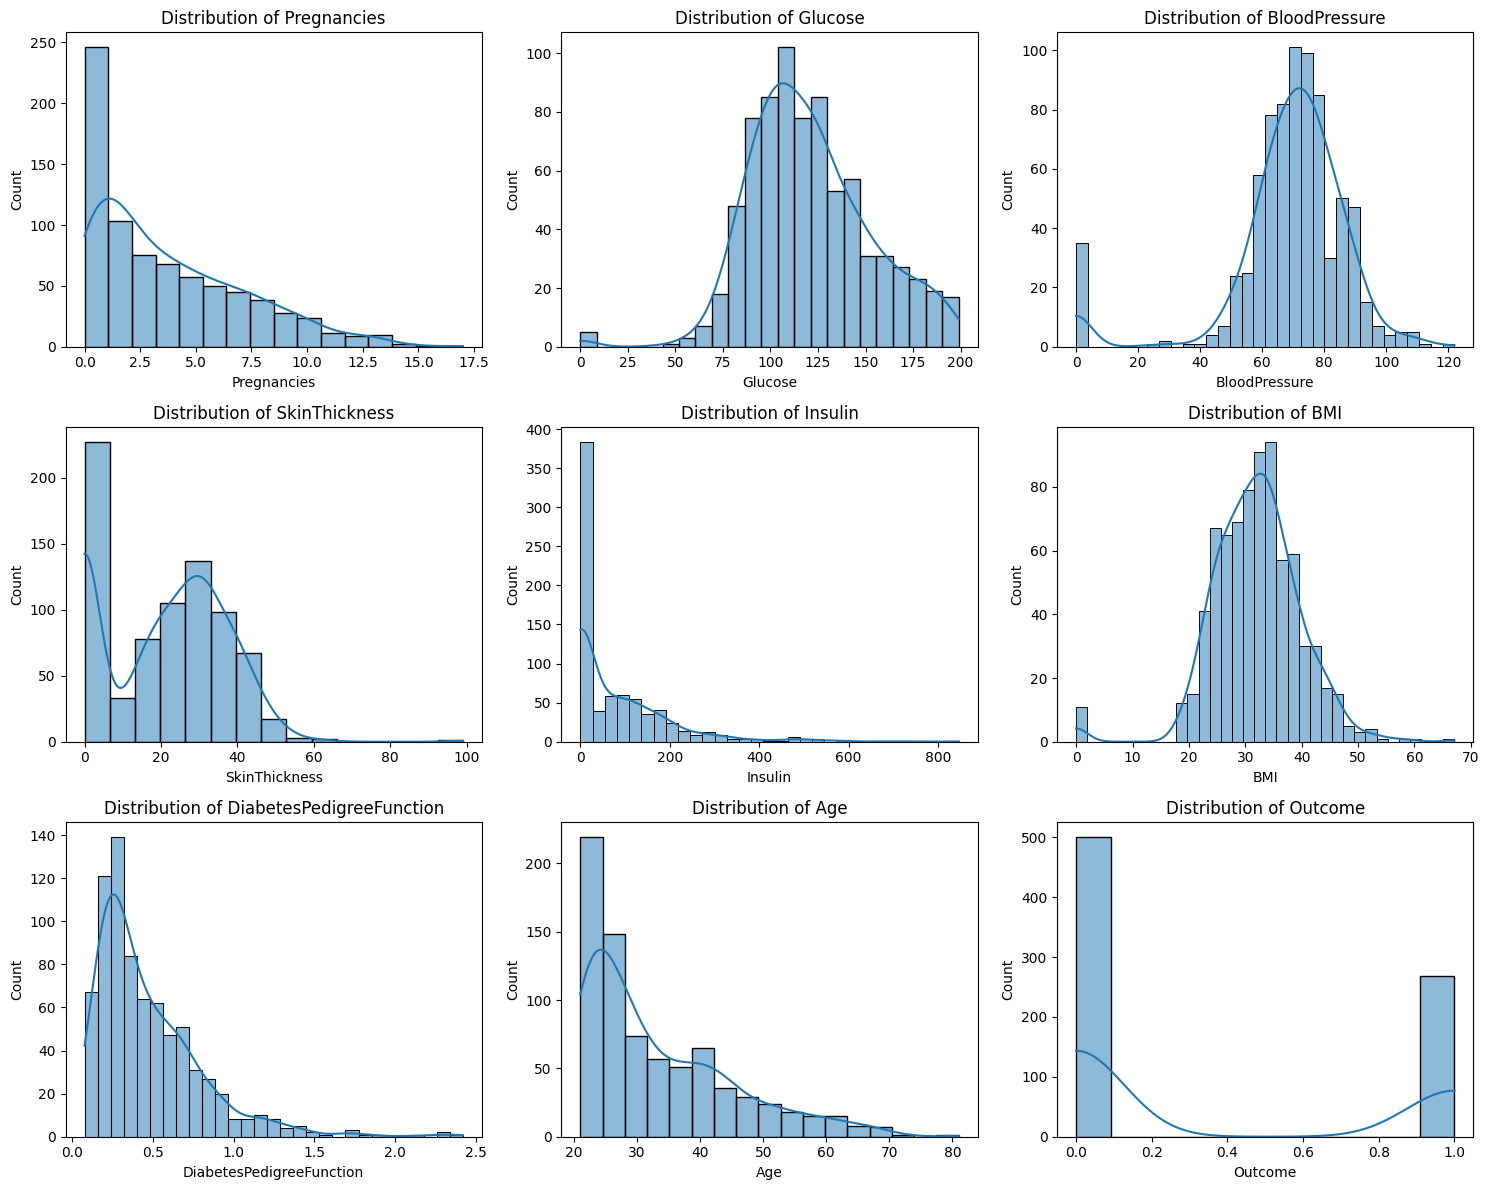

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of each feature
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

plt.figure(figsize=(15, 12))
for i, col in enumerate(columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Pytorch

In [72]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.5.1+cpu
CUDA available: False


In [68]:
df = [[1,2,3],[2,3,4]]